<a href="https://colab.research.google.com/github/Afreen-1517/RETAIL-SALES-ANALYTICS-PROJECT-/blob/main/Retail_Sales_Analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
#Load dataset
df = pd.read_csv('/content/Dataset/Sample - Superstore.csv', encoding='latin1')

# View data
df.head()

# Check missing values
df.isnull().sum()

# Remove duplicates
df = df.drop_duplicates()

# Fill missing values
df = df.fillna(method='ffill')

# Convert date column
df['Order Date'] = pd.to_datetime(df['Order Date'])

# Check data types
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9994 entries, 0 to 9993
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   Row ID         9994 non-null   int64         
 1   Order ID       9994 non-null   object        
 2   Order Date     9994 non-null   datetime64[ns]
 3   Ship Date      9994 non-null   object        
 4   Ship Mode      9994 non-null   object        
 5   Customer ID    9994 non-null   object        
 6   Customer Name  9994 non-null   object        
 7   Segment        9994 non-null   object        
 8   Country        9994 non-null   object        
 9   City           9994 non-null   object        
 10  State          9994 non-null   object        
 11  Postal Code    9994 non-null   int64         
 12  Region         9994 non-null   object        
 13  Product ID     9994 non-null   object        
 14  Category       9994 non-null   object        
 15  Sub-Category   9994 n

/tmp/ipykernel_2330/3495981647.py:15: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df = df.fillna(method='ffill')


In [ ]:
#Exploratory Data Analysis
# Total Sales
total_sales = df['Sales'].sum()
print("Total Sales:", total_sales)

# Sales by Category
category_sales = df.groupby('Category')['Sales'].sum()
print(category_sales)

# Profit by Region
region_profit = df.groupby('Region')['Profit'].sum()
print(region_profit)

# Monthly Sales
df['Month'] = df['Order Date'].dt.month
monthly_sales = df.groupby('Month')['Sales'].sum()
print(monthly_sales)

#top 10 products
df.groupby('Product Name')['Sales'].sum().sort_values(ascending=False).head(10)

Total Sales: 2297200.8603000003
Category
Furniture          741999.7953
Office Supplies    719047.0320
Technology         836154.0330
Name: Sales, dtype: float64
Region
Central     39706.3625
East        91522.7800
South       46749.4303
West       108418.4489
Name: Profit, dtype: float64
Month
1      94924.8356
2      59751.2514
3     205005.4888
4     137762.1286
5     155028.8117
6     152718.6793
7     147238.0970
8     159044.0630
9     307649.9457
10    200322.9847
11    352461.0710
12    325293.5035
Name: Sales, dtype: float64


,Sales
Product Name,
Canon imageCLASS 2200 Advanced Copier,61599.824
Fellowes PB500 Electric Punch Plastic Comb Binding Machine with Manual Bind,27453.384
Cisco TelePresence System EX90 Videoconferencing Unit,22638.480
HON 5400 Series Task Chairs for Big and Tall,21870.576
GBC DocuBind TL300 Electric Binding System,19823.479
GBC Ibimaster 500 Manual ProClick Binding System,19024.500
Hewlett Packard LaserJet 3310 Copier,18839.686
"HP Designjet T520 Inkjet Large Format Printer - 24"" Color",18374.895
GBC DocuBind P400 Electric Binding System,17965.068


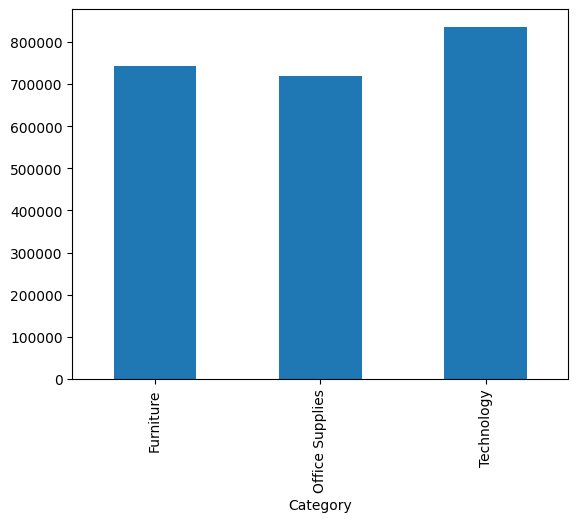

In [ ]:
#visualization
import matplotlib.pyplot as plt

df.groupby('Category')['Sales'].sum().plot(kind='bar')
plt.show()

In [ ]:
# ==============================
# Business Impact Analysis (Retail Sales)
# ==============================

# 1. Top 5 products by sales
top_products = df.groupby('Product Name')['Sales'].sum().sort_values(ascending=False).head(5)
print("Top 5 Products by Sales:\n")
print(top_products)

# 2. Bottom 5 products by sales
low_products = df.groupby('Product Name')['Sales'].sum().sort_values().head(5)
print("\nLow Performing Products:\n")
print(low_products)

# 3. Total sales from top products
total_top_sales = top_products.sum()
print("\nTotal Sales from Top 5 Products: ₹{:.2f}".format(total_top_sales))

# 4. Estimated growth opportunity (5% increase)
growth = total_top_sales * 0.05
print("\nEstimated Revenue Growth Opportunity (5%): ₹{:.2f}".format(growth))

Top 5 Products by Sales:

Product Name
Canon imageCLASS 2200 Advanced Copier                                          61599.824
Fellowes PB500 Electric Punch Plastic Comb Binding Machine with Manual Bind    27453.384
Cisco TelePresence System EX90 Videoconferencing Unit                          22638.480
HON 5400 Series Task Chairs for Big and Tall                                   21870.576
GBC DocuBind TL300 Electric Binding System                                     19823.479
Name: Sales, dtype: float64

Low Performing Products:

Product Name
Eureka Disposable Bags for Sanitaire Vibra Groomer I Upright Vac    1.624
Avery 5                                                             5.760
Xerox 20                                                            6.480
Grip Seal Envelopes                                                 7.072
Avery Hi-Liter Pen Style Six-Color Fluorescent Set                  7.700
Name: Sales, dtype: float64

Total Sales from Top 5 Products: ₹153385.74

Esti

In [ ]:
#Save dataset
df.to_csv('cleaned_data.csv', index=False)